In [12]:
import matplotlib.pyplot as plt
import numpy as np
import time

from numpy import ndarray

In [13]:
def train(input_data, n_max_iterations, width, height):
    σ0 = max(width, height) / 2
    α0 = 0.1
    weights = np.random.random((width, height, 3))
    λ = n_max_iterations / np.log(σ0)
    for t in range(n_max_iterations):
        σt = σ0 * np.exp(-t/λ)
        αt = α0 * np.exp(-t/λ)
        for vt in input_data:
            bmu = np.argmin(np.sum((weights - vt) ** 2, axis=2))
            bmu_x, bmu_y = np.unravel_index(bmu, (width, height))
            for x in range(width):
                for y in range(height):
                    di = np.sqrt(((x - bmu_x) ** 2) + ((y - bmu_y) ** 2))
                    θt = np.exp(-(di ** 2) / (2*(σt ** 2)))
                    weights[x, y] += αt * θt * (vt - weights[x, y])
    return weights

In [36]:
np.random.seed(42)
input_data = np.random.random((10,3))
n_max_iterations = 1000
width = np.arange(4, 51, 4)
height = np.arange(4, 51, 4)

In [37]:
def benchmark(data: ndarray, max_iterations: int, width_l: list[int], height_l: list[int]) -> list[float]:
    results = []
    for l in range(len(width_l)):
        start = time.perf_counter()
        train(data, max_iterations, width_l[l], height_l[l])
        elapsed = time.perf_counter() - start

        results.append(elapsed)

    return results

In [38]:
b_results = benchmark(input_data, n_max_iterations, width, height)

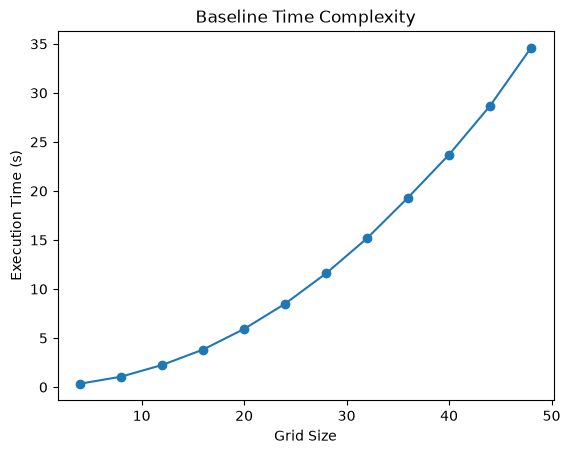

In [39]:
plt.plot(width, b_results, marker="o")
plt.xlabel("Grid Size")
plt.ylabel("Execution Time (s)")
plt.title("Baseline Time Complexity")
plt.savefig("baseline_complexity.png", dpi=300)

plt.show()